In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Data Inspection — CPI (Turkey)

In [3]:
df_cpi = pd.read_csv("../data/raw/cpi_nfne_yoy_turkey.csv")
df_cpi.head()

,observation_date,CPGRLE01TRM659N
0,1994-01-01,71.10177
1,1994-02-01,74.49082
2,1994-03-01,77.25414
3,1994-04-01,101.97450
4,1994-05-01,110.00730


In [5]:
df_cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  376 non-null    object 
 1   CPGRLE01TRM659N   376 non-null    float64
dtypes: float64(1), object(1)
memory usage: 6.0+ KB


In [8]:
df_cpi.shape

(376, 2)

## 2. Data Inspection — WUI

In [16]:
df_t1 = pd.read_excel("../data/raw/wui_monthly_global.xlsx", sheet_name="T1")
df_t1.head()


,Year,Global (simple average),Global (GDP weighted average),Advanced economies,Emerging economies,Low-income economies,Africa,Asia and the Pacific,Europe,Middle East and Central Asia,Western Hemisphere
0,1990q1,9411.204,12496.470,13599.840,8040.513,5142.676,5460.384,6085.133,14842.050,4612.296,15472.910
1,1990q2,9267.289,8769.965,8297.866,11064.610,6629.918,12754.110,9212.479,8833.553,10984.430,8050.245
2,1990q3,13230.890,16198.830,17522.030,10177.310,16612.990,17222.160,13122.700,23189.970,16790.860,10986.880
3,1990q4,10886.610,11872.270,12405.350,9755.987,7821.920,17774.520,13823.930,16097.060,19038.610,5276.455
4,1991q1,9446.463,8223.550,6740.438,14966.600,8688.795,9387.380,4772.079,10867.020,9431.762,7738.637


In [18]:
df_t1.columns

Index(['Year', 'Global (simple average)', 'Global (GDP weighted average)',
       'Advanced economies', 'Emerging economies', 'Low-income economies',
       'Africa', 'Asia and the Pacific', 'Europe',
       'Middle East and Central Asia', 'Western Hemisphere'],
      dtype='object')

In [19]:
df_t1.shape

(144, 11)

## 3. WUI — Cleaning

In [24]:
df_wui = df_t1[["Year", "Global (GDP weighted average)"]].copy()

In [25]:
df_wui = df_wui.rename(columns={
    "Year": "date",
    "Global (GDP weighted average)": "wui_global_gdp"
})

In [26]:
df_wui.head()

,date,wui_global_gdp
0,1990q1,12496.470
1,1990q2,8769.965
2,1990q3,16198.830
3,1990q4,11872.270
4,1991q1,8223.550


In [28]:
df_wui.dtypes

date               object
wui_global_gdp    float64
dtype: object

In [29]:
df_wui["date"] = df_wui["date"].astype(str).str.lower()
df_wui["date"].head()

0    1990q1
1    1990q2
2    1990q3
3    1990q4
4    1991q1
Name: date, dtype: object

In [30]:
df_wui["date"] = pd.PeriodIndex(df_wui["date"], freq="Q").to_timestamp(how="start")
df_wui.dtypes

date              datetime64[ns]
wui_global_gdp           float64
dtype: object

In [31]:
df_wui.head()

,date,wui_global_gdp
0,1990-01-01,12496.470
1,1990-04-01,8769.965
2,1990-07-01,16198.830
3,1990-10-01,11872.270
4,1991-01-01,8223.550


In [32]:
df_wui.isna().sum()

date              0
wui_global_gdp    0
dtype: int64

In [33]:
df_wui["date"].duplicated().sum()

np.int64(0)

In [34]:
df_wui["date"].min(), df_wui["date"].max()

(Timestamp('1990-01-01 00:00:00'), Timestamp('2025-10-01 00:00:00'))

In [35]:
df_wui = df_wui.sort_values("date").reset_index(drop=True)
df_wui.head()

,date,wui_global_gdp
0,1990-01-01,12496.470
1,1990-04-01,8769.965
2,1990-07-01,16198.830
3,1990-10-01,11872.270
4,1991-01-01,8223.550


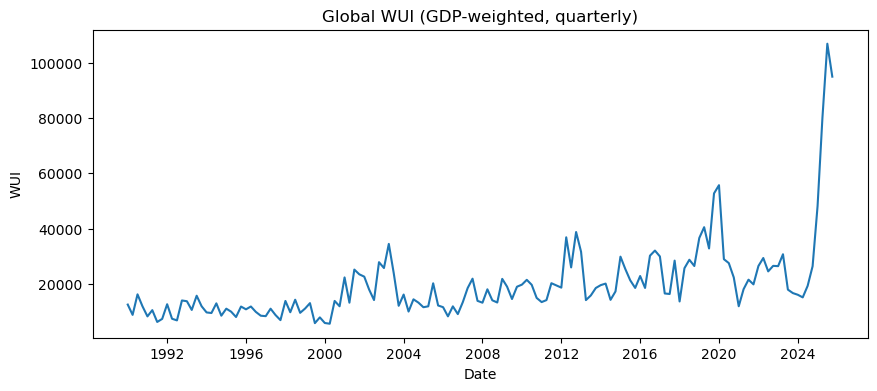

In [37]:
plt.figure(figsize=(10,4))
plt.plot(df_wui["date"], df_wui["wui_global_gdp"])
plt.title("Global WUI (GDP-weighted, quarterly)")
plt.xlabel("Date")
plt.ylabel("WUI")
plt.show()

## 4. CPI (Turkey) — Convert monthly to quarterly

WUI is quarterly, while CPI inflation is monthly.  
To align frequencies, we aggregate monthly CPI (YoY NFNE) to quarterly values.

In [38]:
df_cpi = df_cpi.rename(columns={
    "observation_date": "date",
    "CPGRLE01TRM659N": "cpi_yoy_nfne"
}).copy()

df_cpi["date"] = pd.to_datetime(df_cpi["date"])
df_cpi.dtypes

date            datetime64[ns]
cpi_yoy_nfne           float64
dtype: object

In [39]:
df_cpi_q = (
    df_cpi
    .set_index("date")
    .resample("QS") 
    .mean()
    .reset_index()
)

df_cpi_q.head()

,date,cpi_yoy_nfne
0,1994-01-01,74.282243
1,1994-04-01,107.848267
2,1994-07-01,110.900267
3,1994-10-01,109.544433
4,1995-01-01,111.855033


In [40]:
df_cpi_q.isna().sum()

date            0
cpi_yoy_nfne    0
dtype: int64

In [41]:
df_cpi_q["date"].duplicated().sum()

np.int64(0)

In [42]:
df_cpi_q["date"].min(), df_cpi_q["date"].max()

(Timestamp('1994-01-01 00:00:00'), Timestamp('2025-04-01 00:00:00'))

## 5. Align time ranges (common sample)

In [43]:
start = max(df_wui["date"].min(), df_cpi_q["date"].min())
end   = min(df_wui["date"].max(), df_cpi_q["date"].max())

start, end

(Timestamp('1994-01-01 00:00:00'), Timestamp('2025-04-01 00:00:00'))

In [44]:
df_wui_common = df_wui[(df_wui["date"] >= start) & (df_wui["date"] <= end)].copy()
df_cpi_common = df_cpi_q[(df_cpi_q["date"] >= start) & (df_cpi_q["date"] <= end)].copy()

df_wui_common.shape, df_cpi_common.shape

((126, 2), (126, 2))

In [46]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

df_wui_common.to_csv(processed_dir / "wui_global_gdp_quarterly.csv", index=False)
df_cpi_common.to_csv(processed_dir / "cpi_nfne_yoy_quarterly_mean_turkey.csv", index=False)
